# Text Classification With RNNs

In this demo, we'll use RNNs to find the author of a text.

The corpus comes from classic works of English-language literature: 9 authors, 2 books per author, with one file per chapter.

## Downloading the Data From a Git Repository

In [1]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s classical-authors

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 1215, done.
remote: Counting objects: 100% (1215/1215), done.
remote: Compressing objects: 100% (1215/1215), done.
remote: Total 1215 (delta 0), reused 1215 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1215/1215), 4.22 MiB | 1.71 MiB/s, done.
Updating files: 100% (1215/1215), done.
✓ classical-authors — 1215 fichiers, 12M


## Downloading the spacy Model for English

In [2]:
spacy_updated = !pip freeze | grep spacy==3
if not spacy_updated:
  !pip install 'spacy >= 3, < 4'
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 14.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Importing TensorFlow and the Other Required Libraries

In [3]:
import re
import typing

import matplotlib.pyplot as plt
import numpy
import pathlib
import seaborn
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing
import spacy
import tensorflow as tf
import tqdm.notebook

### Short version

Preparing the sentences with spaCy and the three trainings take time. For a live demonstration, set `SHORT_RUN` to `True` in the next cell: the notebook then uses only one chapter in two, and the last model trains for `10` epochs instead of `30`: the notebook then takes about 5 minutes on a T4, instead of 13. The scores are then a little lower (the figures quoted below are those of the full version).

In [4]:
SHORT_RUN = False

## Preprocessing

- Each sentence is an example
- Every word (or group of words) that is a named entity is replaced by its type (with the first letter tripled to create new "words")

In [5]:
nlp = spacy.load(
    "en_core_web_sm",
    exclude=("tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"))
nlp.enable_pipe("senter")


def replace_ners(tokens: typing.Iterable[spacy.tokens.Token]
                 ) -> typing.Iterator[str]:
  result = []
  for token in tokens:
    if token.ent_iob_ == "O":
      yield token.text
    elif token.ent_iob_ == "B":
      prefix = token.ent_type_[0]
      yield f"{prefix}{prefix}{token.ent_type_}"


def get_data(directory: pathlib.Path,
             ) -> typing.Tuple[typing.List[str], typing.List[str]]:
  texts = []
  authors = []
  paths = sorted(directory.glob("*/*/*.txt"))
  if SHORT_RUN:
    # One chapter in two of each book.
    paths = paths[::2]
  contents = (p.read_text(encoding="utf8").replace("\n", " ") for p in paths)
  for path, doc in tqdm.notebook.tqdm(zip(paths, nlp.pipe(contents,
                                                          n_process=1)),
                                      total=len(paths)):

    author = path.parent.parent.name
    for sentence in doc.sents:
      authors.append(author)
      texts.append(" ".join(replace_ners(sentence)))

  return texts, authors


texts, authors = get_data(pathlib.Path("classical-authors"))

label_encoder = sklearn.preprocessing.LabelEncoder()
y = label_encoder.fit_transform(authors)

print("Number of texts and shape of y:", len(texts), y.shape)

X_train_raw, X_test_raw, y_train, y_test = \
    sklearn.model_selection.train_test_split(texts, y, test_size=0.3)

  0%|          | 0/1214 [00:00<?, ?it/s]

Number of texts and shape of y: 74972 (74972,)


In [6]:
print(len(X_train_raw), y_train.shape)

52480 (52480,)


## Preparing the Data as Sequences

### Preparing the Dictionary and the Sequences

With the [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) tool, we'll:
- Build a dictionary on the `X_train_raw` corpus
- Find the vocabulary size
- Find the maximum length, in words, of a sentence

In [7]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(X_train_raw)

In [8]:
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(s.split()) for s in X_train_raw)
print(f"Vocabulary size: {vocab_size}")
print(f"Length of the longest word sequence: {max_length}")

Vocabulary size: 31795
Length of the longest word sequence: 530


### Building the Matrix of Index Sequences

With the [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) and [`tf.keras.preprocessing.sequence.pad_sequences`](https://keras.io/api/preprocessing/timeseries/#padsequences-function) tools, we'll:
- Turn `X_train_raw` and `X_test_raw` into sequences of word indices in a dictionary (``texts_to_sequences()`` function of the ``Tokenizer`` object instantiated previously)
- **Pad** the sequences so that they have a reasonable length to be processed by a bidirectional GRU:
  - Use `maxlen = 150`, because beyond that, GRUs start failing to properly carry the information.
- Store the resulting sequences in `X_train_pad` and `X_test_pad`

In [9]:
max_length = 150

X_train_tokens = tokenizer.texts_to_sequences(X_train_raw)
X_test_tokens = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_tokens, maxlen=max_length, truncating="pre")
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_tokens, maxlen=max_length, truncating="pre")

In [10]:
print(f"Input shape: {X_train_pad.shape}")
print(f"First example: {X_train_pad[0]}")

Input shape: (52480, 150)
First example: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
   13   91   28  251   29   36   45  327   96 3428]


## Modeling

Let's build a model with the following characteristics:
  - An embedding layer of size 300
  - A layer of bidirectional GRUs (Bidirectional is a Keras layer):
    - of size `64`
    - an orthogonal initialization of **the** weight matrices
    - a dropout parameter of `0.2` for the forward parts
  - A neural network layer with a `softmax` activation that takes as input the last output of the [`GRU`](https://keras.io/api/layers/recurrent_layers/gru/) layer
  - A **cross-entropy** based loss function
  - The `adam` optimizer
  - `accuracy` as the evaluation metric

In [11]:
EMBEDDING_DIM = 300

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(max_length,)))
model.add(tf.keras.layers.Embedding(vocab_size, EMBEDDING_DIM))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64,
                        kernel_initializer="orthogonal",
                        recurrent_initializer="orthogonal",
                        dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 300)       │     9,538,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       140,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,680,205 (36.93 MB)

 Trainable params: 9,680,205 (36.93 MB)

 Non-trainable params: 0 (0.00 B)

## Training

Let's train our model on `X_train_pad`:
- with batches of size `1024`
- for `10` epochs
- using 30% of the training set for validation

In [12]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=10,
          validation_split=0.3)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.2353 - loss: 2.0257 - val_accuracy: 0.3067 - val_loss: 1.8813
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.3581 - loss: 1.7395 - val_accuracy: 0.3986 - val_loss: 1.6270
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.5031 - loss: 1.3990 - val_accuracy: 0.4902 - val_loss: 1.4148
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.6293 - loss: 1.0924 - val_accuracy: 0.5200 - val_loss: 1.3439
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.7145 - loss: 0.8545 - val_accuracy: 0.5452 - val_loss: 1.3332
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.7723 - loss: 0.6852 - val_accuracy: 0.5488 - val_loss: 1.3496
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8125 - loss: 0.5664 - val_accuracy: 0.5548 - val_loss: 1.3938
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8389 - loss: 0.4875 - val_accuracy: 0

## Evaluation

Evaluate your model's performance on the test set.

In [13]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, batch_size=1024)
print(f"Test set accuracy: {test_accuracy:.3f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5649 - loss: 1.5406
Test set accuracy: 0.565


## First Conclusions

We observe overfitting: train $\approx$ 85% while validation and test $\approx$ 55% (full version)

## Using Pre-Trained Word Embeddings

To get better results, we'll use the pre-trained GloVe embeddings, rather than learning specific embeddings as before.

In [14]:
!wget -q https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       
  inflating: glove.6B.50d.txt        


In [15]:
def glove_path(embedding_dim: int) -> pathlib.Path:
  if embedding_dim in {50, 100, 200, 300}:
    return pathlib.Path("glove.6B.{}d.txt".format(embedding_dim))
  else:
    raise ValueError("embedding_dim must be in {50, 100, 200, 300}")

## Reusing the GloVe Word Embeddings

Keras' Embedding layer can be initialized with a weight matrix where row i is the embedding of word i.

After a quick look at the `glove.6B.300d.txt` files, we'll:
- create a layer `embedding_layer` of type [`tensorflow.keras.layers.Embedding`](https://keras.io/api/layers/core_layers/embedding/):
  - initialize it with the GloVe embeddings.
  - initialize the words of our vocabulary that aren't in GloVe with the zero vector
  - use the appropriate flag to prevent these embeddings from changing during training

In [16]:
embedding_matrix = numpy.zeros((vocab_size, EMBEDDING_DIM))
found = 0
with glove_path(EMBEDDING_DIM).open() as fh:
  for line in fh:
    values = line.split(" ")
    word = values[0]
    if word in tokenizer.word_index:
      found += 1
      coeffs = numpy.array(values[1:], dtype="float32")
      embedding_matrix[tokenizer.word_index[word]] = coeffs

print(f"Using {found} pre-trained embeddings out of {vocab_size} words "
      "in the vocabulary")

embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                            EMBEDDING_DIM,
                                            weights=[embedding_matrix],
                                            trainable=False)

Using 27610 pre-trained embeddings out of 31795 words in the vocabulary


## Modeling, Training and Evaluation

We'll:

- Create a model identical to the one of the previous part, except that the embedding layer is the one we just instantiated from GloVe
- Train this model with the same parameters as in the previous part, but for `20` epochs instead of `10`: the frozen embeddings limit overfitting, which allows a longer training
- Evaluate it on the test data

NB: a deeper model, which does better, is proposed in the next part.

In [17]:
model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64,
                        kernel_initializer="orthogonal",
                        recurrent_initializer="orthogonal",
                        dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation ="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,538,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,538,500 (36.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,538,500 (36.39 MB)

In [18]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=20,
          validation_split=0.3)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.2479 - loss: 2.0327 - val_accuracy: 0.3143 - val_loss: 1.8640
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.3430 - loss: 1.7702 - val_accuracy: 0.3977 - val_loss: 1.6425
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.4200 - loss: 1.5880 - val_accuracy: 0.4529 - val_loss: 1.5105
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.4536 - loss: 1.5031 - val_accuracy: 0.4789 - val_loss: 1.4533
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.4764 - loss: 1.4474 - val_accuracy: 0.4963 - val_loss: 1.4020
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4977 - loss: 1.3929 - val_accuracy: 0.5133 - val_loss: 1.3582
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5179 - loss: 1.3464 - val_accuracy: 0.5257 - val_loss: 1.3249
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.5276 - loss: 1.3120 - val_accuracy: 0.5

In [19]:
model.evaluate(X_test_pad, y_test)

703/703 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5759 - loss: 1.1921


[1.1921316385269165, 0.5758936405181885]

## A Deeper Model

In [20]:
bidi_gru_params = dict(kernel_initializer="orthogonal",
                       recurrent_initializer="orthogonal",
                       dropout=0.5)

model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params, return_sequences=True)))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 300)       │     9,538,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,538,500 (36.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,538,500 (36.39 MB)

In [21]:
scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.1, patience=5)

model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=10 if SHORT_RUN else 30,
          validation_split=0.3,
          callbacks=[scheduler])

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 343ms/step - accuracy: 0.2634 - loss: 1.9739 - val_accuracy: 0.3429 - val_loss: 1.7568 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.3601 - loss: 1.7129 - val_accuracy: 0.4358 - val_loss: 1.5621 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 331ms/step - accuracy: 0.4134 - loss: 1.5976 - val_accuracy: 0.4668 - val_loss: 1.4847 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.4429 - loss: 1.5269 - val_accuracy: 0.4898 - val_loss: 1.4274 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.4677 - loss: 1.4691 - val_accuracy: 0.5114 - val_loss: 1.3640 - learning_rate: 0.0010
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.4827 - loss: 1.4244 - val_accuracy: 0.5208 - val_loss: 1.3313 - learning_rate: 0.0010
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.4978 - loss: 1.

In [22]:
model.evaluate(X_test_pad, y_test)

703/703 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6015 - loss: 1.1303


[1.1303071975708008, 0.6015472412109375]

## Displaying the Test Confusion Matrix

Let's display the confusion matrix (using a heatmap is recommended).

In [23]:
y_pred_softmax = model.predict(X_test_pad)
y_pred = numpy.argmax(y_pred_softmax , axis=1)

703/703 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step


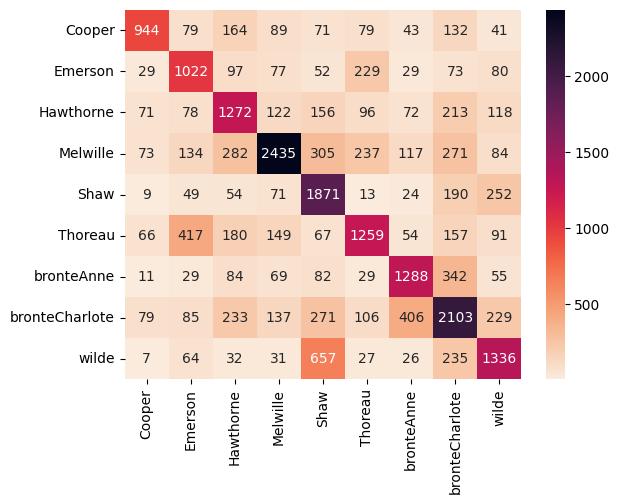

In [24]:
conf_mat = sklearn.metrics.confusion_matrix(y_test, y_pred)
seaborn.heatmap(conf_mat,
                annot=True,
                fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="rocket_r")
plt.show()

## Interpretation

Figures of the full version:

- The last model finds the author of **a single sentence**, often a very short one, in about 62% of cases. With 9 authors, answering at random would give 11%, and always answering the author with the most sentences (Melville) about 18%: so the model did learn features of style.
- The confusion matrix (rows: true author, columns: predicted author) shows where it goes wrong: between the two Brontë sisters, between Emerson and Thoreau (two American essayists of the same school of thought), and between Wilde and Shaw (here, four plays, made of dialogue). Its errors concern authors close in period, genre or style, as a reader's would.

## Takeaways

- For a neural network, a text is a sequence of words turned into numbers (*embeddings*); an RNN (here a GRU) reads it word by word.
- The first model overfits (85% on training, 55% on test): only the score on data the model has never seen counts.
- Embeddings pre-trained on a large corpus (GloVe), then a deeper model, gain a few points (from about 55% to 62%).
- A score is read against a baseline (random guessing, the most frequent class), and the confusion matrix tells which classes the model confuses.
- For text, transformers have since largely replaced RNNs.